# DATA EXPLORATION
Tasks achieved through this notebook:
1. Loading the Data
2. Understanding the Schema 
3. Inspecting the candidates
4. Keyword exploration
5. Trap and Suitable candidate analysis
6. Visualisations

In [35]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
import os 
os.listdir("../data/")

['.DS_Store',
 'candidates.jsonl',
 'candidate_schema.json',
 'job_description.docx',
 'README.docx',
 'redrob_signals_doc.docx',
 'sample_candidates.json',
 'sample_submission.csv',
 'submission_metadata_template.yaml',
 'submission_spec.docx',
 'validate_submission.py']

In [37]:
candidates = []

with open("../data/candidates.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        candidates.append(json.loads(line))

        if len(candidates) == 1000:
            break
print("Loaded:", len(candidates), "candidates from the candidates.jsonl file.")

Loaded: 1000 candidates from the candidates.jsonl file.


In [38]:
import pprint

candidate = candidates[0]
print(candidate.keys())
print()
print("Candidate 1  INFO:")
pprint.pprint(candidate)

dict_keys(['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals'])

Candidate 1  INFO:
{'candidate_id': 'CAND_0000001',
 'career_history': [{'company': 'Mindtree',
                     'company_size': '10001+',
                     'description': 'Implemented streaming data pipelines on '
                                    'Kafka and Spark Streaming for a real-time '
                                    'user-activity processing platform. '
                                    'Designed the schema-registry integration, '
                                    'the watermark/state management approach, '
                                    'and the deduplication logic for '
                                    'late-arriving events. Worked closely with '
                                    'the data science team to make sure '
                                    'feature pipelines aligned with what their '
                         

In [39]:
with open("../data/sample_candidates.json", "r", encoding="utf-8") as f:
    sample_candidates = json.load(f)

print(len(sample_candidates))
print()
print(sample_candidates[0].keys())


50

dict_keys(['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals'])


In [40]:
print(sample_candidates[0]["profile"].keys())
print()
print(sample_candidates[0]["career_history"][0].keys())
print()
print(sample_candidates[0]["skills"][0].keys())
print()
print(sample_candidates[0]["redrob_signals"].keys())
print()
pprint.pprint(sample_candidates[0])

dict_keys(['anonymized_name', 'headline', 'summary', 'location', 'country', 'years_of_experience', 'current_title', 'current_company', 'current_company_size', 'current_industry'])

dict_keys(['company', 'title', 'start_date', 'end_date', 'duration_months', 'is_current', 'industry', 'company_size', 'description'])

dict_keys(['name', 'proficiency', 'endorsements', 'duration_months'])

dict_keys(['profile_completeness_score', 'signup_date', 'last_active_date', 'open_to_work_flag', 'profile_views_received_30d', 'applications_submitted_30d', 'recruiter_response_rate', 'avg_response_time_hours', 'skill_assessment_scores', 'connection_count', 'endorsements_received', 'notice_period_days', 'expected_salary_range_inr_lpa', 'preferred_work_mode', 'willing_to_relocate', 'github_activity_score', 'search_appearance_30d', 'saved_by_recruiters_30d', 'interview_completion_rate', 'offer_acceptance_rate', 'verified_email', 'verified_phone', 'linkedin_connected'])

{'candidate_id': 'CAND_0000001',
 'car

In [41]:
#scale level inspection of data 

from collections import Counter

print("most common current titles:")
titles = Counter()
for c in sample_candidates:
    titles[c["profile"]["current_title"]] += 1
print(titles.most_common(20))
print()

print("most common skills:")
skills = Counter()
for c in sample_candidates:
    for s in c["skills"]:
        skills[s["name"]] += 1
print(skills.most_common(30))
print()

print("most common companies:")
companies = Counter()
for c in sample_candidates:
    companies[c["profile"]["current_company"]] += 1
print(companies.most_common(20))

most common current titles:
[('Operations Manager', 5), ('Business Analyst', 5), ('Mechanical Engineer', 5), ('Project Manager', 5), ('Frontend Engineer', 4), ('Marketing Manager', 3), ('Accountant', 3), ('Customer Support', 2), ('Civil Engineer', 2), ('Software Engineer', 2), ('HR Manager', 2), ('Graphic Designer', 2), ('Backend Engineer', 1), ('Data Engineer', 1), ('QA Engineer', 1), ('DevOps Engineer', 1), ('Recommendation Systems Engineer', 1), ('.NET Developer', 1), ('Full Stack Developer', 1), ('Java Developer', 1)]

most common skills:
[('AWS', 10), ('Data Pipelines', 10), ('Node.js', 9), ('Sales', 9), ('Figma', 9), ('Tailwind', 8), ('GCP', 8), ('Content Writing', 8), ('GraphQL', 8), ('gRPC', 8), ('Terraform', 8), ('Scrum', 8), ('Java', 8), ('Spring Boot', 8), ('Hadoop', 8), ('ETL', 8), ('Weights & Biases', 7), ('React', 7), ('TypeScript', 7), ('Kubernetes', 7), ('Redux', 7), ('Airflow', 7), ('SAP', 7), ('SQL', 7), ('Spark', 7), ('Azure', 7), ('Photoshop', 6), ('Apache Beam', 6)

In [42]:
for c in sample_candidates[:10]:
    print(
        c["profile"]["current_title"],":", c["profile"]["current_company"], ":",
        c["profile"]["years_of_experience"]
    )

Backend Engineer : Mindtree : 6.9
Operations Manager : Wipro : 12.5
Customer Support : TCS : 1.1
Marketing Manager : Dunder Mifflin : 3.8
Accountant : Stark Industries : 11.0
Business Analyst : Wayne Enterprises : 6.0
Civil Engineer : Wipro : 5.5
Operations Manager : Wipro : 3.6
Mechanical Engineer : Dunder Mifflin : 11.0
Data Engineer : Ola : 4.6


In [43]:
#experience distribution
exp = [
    c["profile"]["years_of_experience"]
    for c in candidates
]

print("Experience distribution in years :")
print("Min:", min(exp))
print("Max:", max(exp))
print("Mean:", round(np.mean(exp), 2))
print("Median:", round(np.median(exp), 2))

Experience distribution in years :
Min: 1.1
Max: 15.0
Mean: 6.89
Median: 6.3


In [44]:
industries = Counter(
    c["profile"]["current_industry"]
    for c in candidates
)

print("Most common industries:")
for industry, count in industries.most_common(20):
    print(f"  {industry}: {count}")

print()
print("Total open to work candidates:", sum(
    c["redrob_signals"]["open_to_work_flag"]
    for c in candidates
))
print()
notice = [
    c["redrob_signals"]["notice_period_days"]
    for c in candidates
]
print("Notice period distribution in days :",np.mean(notice))


Most common industries:
  IT Services: 295
  Manufacturing: 226
  Software: 214
  Paper Products: 73
  Conglomerate: 71
  Food Delivery: 35
  Fintech: 33
  Consulting: 19
  E-commerce: 12
  EdTech: 9
  SaaS: 3
  AI/ML: 2
  HealthTech: 2
  Gaming: 2
  Transportation: 1
  Conversational AI: 1
  AdTech: 1
  HealthTech AI: 1

Total open to work candidates: 346

Notice period distribution in days : 87.165


In [45]:
JD_KEYWORDS = [
    "retrieval",
    "ranking",
    "search",
    "recommendation",
    "embedding",
    "vector",
    "elasticsearch",
    "opensearch",
    "faiss",
    "pinecone",
    "milvus",
    "qdrant",
    "weaviate",
    "semantic",
    "recommender"
]

In [46]:

# this function counts the number of keywords in a candidate's profile, 
# career history, and skills, 
# and returns the count along with the matched keywords.
def candidate_mentions_keywords(candidate):
    text = ""

    # Profile
    profile = candidate["profile"]
    text += (profile.get("headline") or "") + " "
    text += (profile.get("summary") or "") + " "

    # Career history
    for job in candidate["career_history"]:
        text += (job.get("title") or "") + " "
        text += (job.get("description") or "") + " "

    # Skills
    for skill in candidate["skills"]:
        text += (skill.get("name") or "") + " "

    # Convert to lowercase
    text = text.lower()

    # Count unique keyword matches
    count = 0
    matched_keywords = []

    for word in JD_KEYWORDS:
        if word.lower() in text:
            count += 1
            matched_keywords.append(word)

    return count, matched_keywords


# Score all candidates
scores = []

for c in candidates:
    score, matched = candidate_mentions_keywords(c)

    scores.append({
        "candidate_id": c["candidate_id"],
        "current_title": c["profile"]["current_title"],
        "keyword_score": score,
        "matched_keywords": ", ".join(matched)
    })

# Convert to DataFrame
scores_df = pd.DataFrame(scores)

# Sort by score
scores_df = scores_df.sort_values(
    by="keyword_score",
    ascending=False
).reset_index(drop=True)

# Show top candidates
scores_df.head(20)

,candidate_id,current_title,keyword_score,matched_keywords
0,CAND_0000399,Business Analyst,8,"retrieval, search, recommendation, embedding, ..."
1,CAND_0000932,Operations Manager,8,"retrieval, search, recommendation, embedding, ..."
2,CAND_0000576,Content Writer,8,"retrieval, search, recommendation, embedding, ..."
3,CAND_0000212,Customer Support,8,"retrieval, search, recommendation, embedding, ..."
4,CAND_0000220,Marketing Manager,8,"retrieval, search, recommendation, embedding, ..."
5,CAND_0000847,HR Manager,8,"retrieval, search, recommendation, embedding, ..."
6,CAND_0000862,Content Writer,8,"retrieval, search, recommendation, embedding, ..."
7,CAND_0000981,ML Engineer,8,"retrieval, ranking, search, recommendation, ve..."
8,CAND_0000821,Mechanical Engineer,8,"retrieval, search, recommendation, embedding, ..."
9,CAND_0000505,Accountant,7,"search, recommendation, embedding, vector, fai..."


In [47]:
KEYWORD_WEIGHTS = {
    "retrieval": 5,
    "ranking": 5,
    "recommendation": 5,
    "recommender": 5,
    "search": 4,
    "embedding": 4,
    "embeddings": 4,
    "vector": 3,
    "faiss": 5,
    "pinecone": 5,
    "milvus": 5,
    "qdrant": 5,
    "weaviate": 5,
    "elasticsearch": 4,
    "opensearch": 4,
    "semantic": 3
}

In [48]:
#function to calculate a weighted keyword score for a candidate 
# based on the presence of keywords in their profile, career history, and skills.

def keyword_score(candidate):
    text = ""

    profile = candidate["profile"]

    text += (profile.get("headline") or "") + " "
    text += (profile.get("summary") or "") + " "

    for job in candidate["career_history"]:
        text += (job.get("title") or "") + " "
        text += (job.get("description") or "") + " "

    for skill in candidate["skills"]:
        text += (skill.get("name") or "") + " "

    text = text.lower()

    score = 0

    for word, weight in KEYWORD_WEIGHTS.items():
        if word in text:
            score += weight

    return score

In [49]:
candidate = next(
    c for c in candidates
    if c["candidate_id"] == "CAND_0000399"
)

print("Title:", candidate["profile"]["current_title"])
print("Company:", candidate["profile"]["current_company"])
print("Experience:", candidate["profile"]["years_of_experience"])
print("Summary:")
print(candidate["profile"]["summary"])

for job in candidate["career_history"]:
    print("\n")
    print(job["title"])
    print(job["description"])

print("\nSkills:")
for skill in candidate["skills"]:
    print(skill["name"])

Title: Business Analyst
Company: Wayne Enterprises
Experience: 12.9
Summary:
Business Analyst with 12.9+ years of experience driving outcomes in my domain. I have built strong functional expertise in the typical responsibilities of the role, including team management, stakeholder communication, and project delivery. Recently I've been excited about how AI and GenAI tools can augment my work. I've been taking online courses on RAG and vector databases, experimenting with LangChain and the OpenAI API for side projects, and exploring how LLMs can streamline workflows in my current function. Open to roles that combine my existing domain experience with emerging AI technologies — I think the most interesting opportunities are at this intersection. Looking for positions where I can contribute both my functional expertise and grow my AI capabilities.


Business Analyst
Enterprise sales of cloud software solutions into the mid-market segment. Carried a $1.8M ARR quota and consistently delivere

In [50]:
candidate = next(
    c for c in candidates
    if c["candidate_id"] == "CAND_0000031"
)

print("Title:", candidate["profile"]["current_title"])
print("Company:", candidate["profile"]["current_company"])
print("Experience:", candidate["profile"]["years_of_experience"])
print("\nSummary:\n")
print(candidate["profile"]["summary"])

print("\nCareer History:")
for job in candidate["career_history"]:
    print("\n", job["title"])
    print(job["description"])

print("\nSkills:")
for skill in candidate["skills"]:
    print(skill["name"])

Title: Recommendation Systems Engineer
Company: Swiggy
Experience: 6.0

Summary:

Machine learning engineer with 6.0 years of experience building ML-powered features in production. Strong background in NLP, recommendation systems, and applied AI; comfortable across the ML stack from feature engineering through deployment. Recently, I led the team that migrated our keyword-search-based product to embedding-based retrieval. I've learned that most retrieval problems are actually evaluation problems in disguise. My academic background is in CS/ML but my main learning has come from shipping real systems and seeing what holds up under production load. Open to senior IC roles in applied ML or AI engineering, ideally at product companies where I'd own a meaningful piece of the ML stack.

Career History:

 Recommendation Systems Engineer
Trained and shipped multiple ranking models for our product's discovery feed using XGBoost and LightGBM. Designed features across three families: content metad

# Insights from Data Exploration

1. Skills alone cannot be trusted.
2. Career evidence matters more than keywords.
3. Production experience matters more than courses.
4. Retrieval/searching experience is the strongest signal.
5. Behavioral signals matter because recruitability matters.
6. Need a credibility score to avoid traps.

# VISUALIZATION OF THE ABOVE DATA 


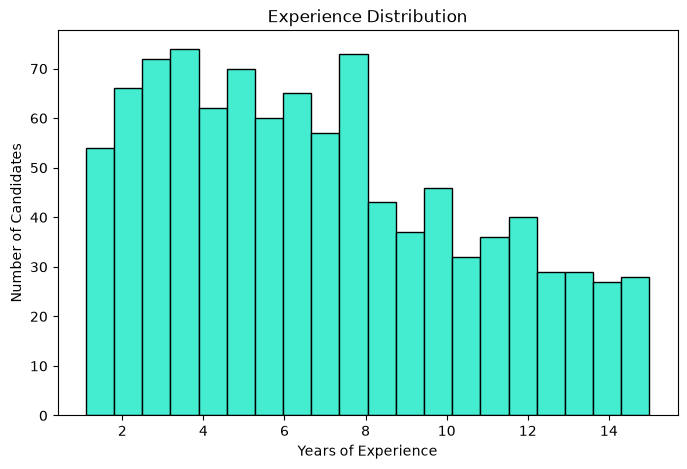

In [51]:
#experience distribution visualization

plt.figure(figsize=(8,5))
plt.hist(exp, bins=20,color="#44ecd0", edgecolor='black')
plt.xlabel("Years of Experience")
plt.ylabel("Number of Candidates")
plt.title("Experience Distribution")
plt.show()

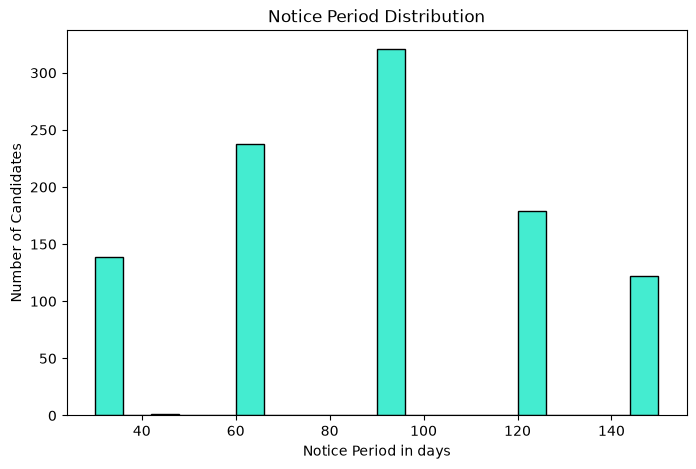

In [52]:
#Notice period distribution
plt.figure(figsize=(8,5))
plt.hist(notice, bins=20,color='#44ecd0', edgecolor='black')
plt.xlabel("Notice Period in days")
plt.ylabel("Number of Candidates")
plt.title("Notice Period Distribution")
plt.show()

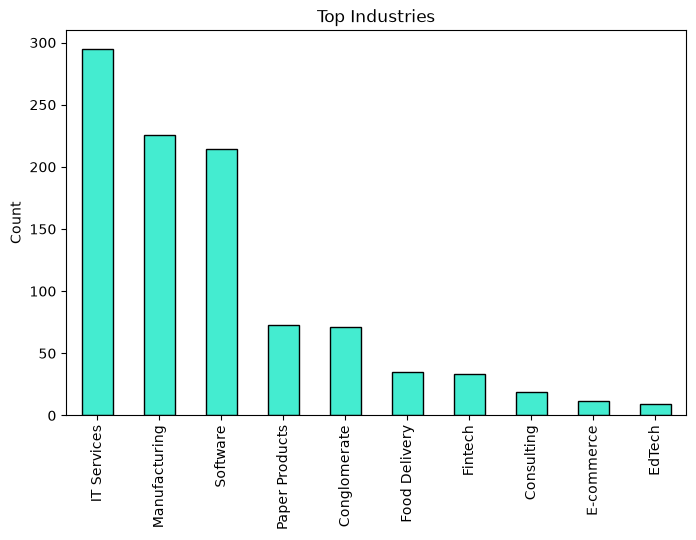

In [53]:
pd.Series(dict(industries.most_common(10))).plot(kind="bar",figsize=(8,5), color='#44ecd0', edgecolor='black')
plt.title("Top Industries")
plt.ylabel("Count")
plt.show()

# Key Takeaways

The dataset is intentionally noisy and contains misleading candidates.

Simple keyword matching fails because:
- candidates can list AI skills without professional experience,
- recent courses and side projects are not enough,
- career history provides stronger evidence than skills alone.

The ranking system would be fail-safe  by considering:
1. Technical capability
2. Career evidence
3. Recruitability
4. Credibility
5. Behavioral signals
